In [11]:
import numpy as np # sir model

def sir_derivatives(t, y, beta, gamma, N):
    S, I, R = y

    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I

    return np.array([dSdt, dIdt, dRdt])

In [16]:
import numpy as np

# Euler Method Solver
def euler_solver(f, y0, t0, t_end, h, beta, gamma, N):

    t_values = np.arange(t0, t_end + h, h)

    y_values = np.zeros((len(t_values), len(y0)))

    # Initial conditions
    y_values[0] = y0

    # Euler iteration
    for i in range(1, len(t_values)):

        t = t_values[i - 1]
        y = y_values[i - 1]

        y_values[i] = y + h * f(t, y, beta, gamma, N)

    return t_values, y_values

In [19]:
import numpy as np

# RK4 Solver
def rk4_solver(f, y0, t0, t_end, h, beta, gamma, N):

    t_values = np.arange(t0, t_end + h, h)

    y_values = np.zeros((len(t_values), len(y0)))

    # Initial conditions
    y_values[0] = y0

    # RK4 iteration
    for i in range(1, len(t_values)):

        t = t_values[i - 1]
        y = y_values[i - 1]

        k1 = f(t, y, beta, gamma, N)

        k2 = f(
            t + h/2,
            y + (h/2) * k1,
            beta,
            gamma,
            N
        )

        k3 = f(
            t + h/2,
            y + (h/2) * k2,
            beta,
            gamma,
            N
        )

        k4 = f(
            t + h,
            y + h * k3,
            beta,
            gamma,
            N
        )

        y_values[i] = y + (h/6) * (k1 + 2*k2 + 2*k3 + k4)

    return t_values, y_values

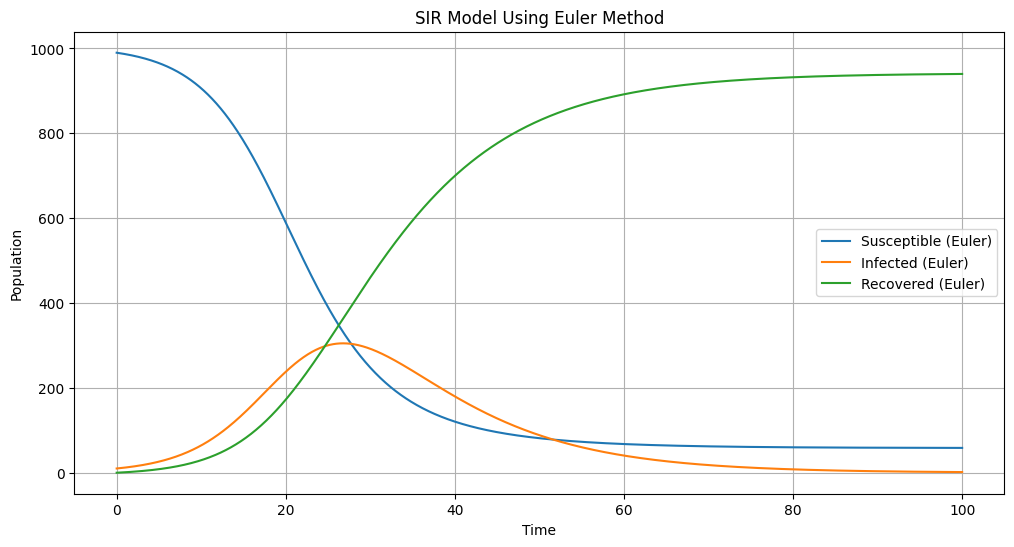

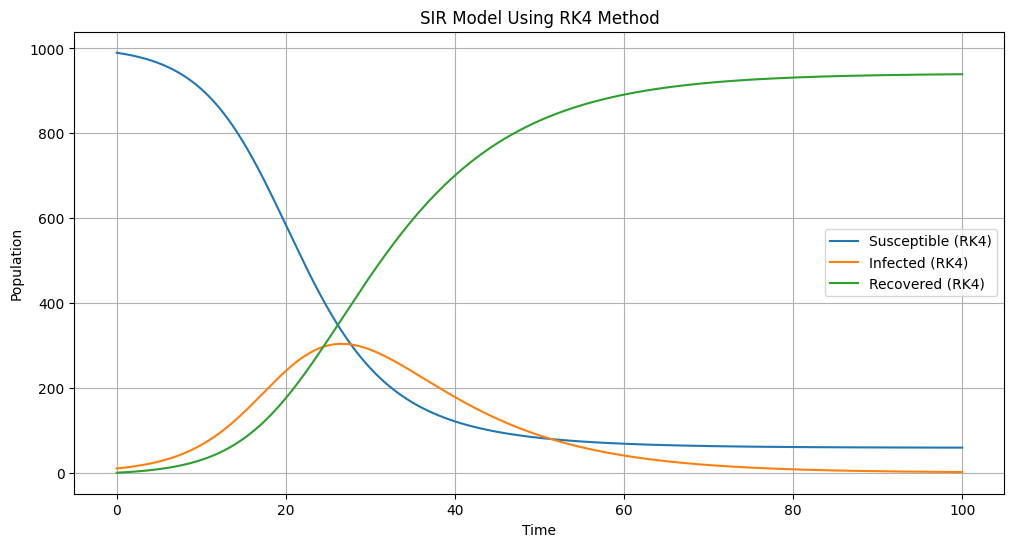

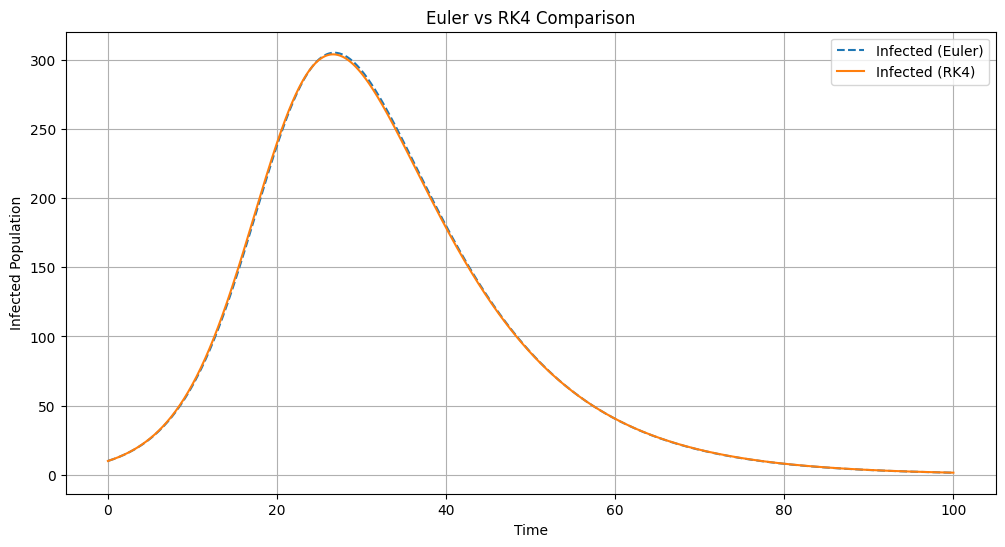

Euler Peak Infection: 304.98765021889074
RK4 Peak Infection: 303.8112113112408


In [22]:
# Install packages if needed
# Run this once in Jupyter if numpy/matplotlib are missing

# !pip install numpy matplotlib


# =========================================================
# IMPORTS
# =========================================================

import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# SIR MODEL
# =========================================================

def sir_derivatives(t, y, beta, gamma, N):

    S, I, R = y

    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I

    return np.array([dSdt, dIdt, dRdt])


# =========================================================
# EULER SOLVER
# =========================================================

def euler_solver(f, y0, t0, t_end, h, beta, gamma, N):

    t_values = np.arange(t0, t_end + h, h)

    y_values = np.zeros((len(t_values), len(y0)))

    # Initial conditions
    y_values[0] = y0

    # Euler iterations
    for i in range(1, len(t_values)):

        t = t_values[i - 1]
        y = y_values[i - 1]

        y_values[i] = y + h * f(t, y, beta, gamma, N)

    return t_values, y_values


# =========================================================
# RK4 SOLVER
# =========================================================

def rk4_solver(f, y0, t0, t_end, h, beta, gamma, N):

    t_values = np.arange(t0, t_end + h, h)

    y_values = np.zeros((len(t_values), len(y0)))

    # Initial conditions
    y_values[0] = y0

    # RK4 iterations
    for i in range(1, len(t_values)):

        t = t_values[i - 1]
        y = y_values[i - 1]

        k1 = f(t, y, beta, gamma, N)

        k2 = f(
            t + h/2,
            y + (h/2) * k1,
            beta,
            gamma,
            N
        )

        k3 = f(
            t + h/2,
            y + (h/2) * k2,
            beta,
            gamma,
            N
        )

        k4 = f(
            t + h,
            y + h * k3,
            beta,
            gamma,
            N
        )

        y_values[i] = y + (h/6) * (k1 + 2*k2 + 2*k3 + k4)

    return t_values, y_values


# =========================================================
# PARAMETERS
# =========================================================

N = 1000

S0 = 990
I0 = 10
R0 = 0

beta = 0.3
gamma = 0.1

t0 = 0
t_end = 100

# Try changing:
# h = 0.5
# h = 0.1
# h = 0.01

h = 0.1

y0 = [S0, I0, R0]


# =========================================================
# RUN EULER SIMULATION
# =========================================================

t_euler, y_euler = euler_solver(
    sir_derivatives,
    y0,
    t0,
    t_end,
    h,
    beta,
    gamma,
    N
)


# =========================================================
# RUN RK4 SIMULATION
# =========================================================

t_rk4, y_rk4 = rk4_solver(
    sir_derivatives,
    y0,
    t0,
    t_end,
    h,
    beta,
    gamma,
    N
)


# =========================================================
# EXTRACT RESULTS
# =========================================================

S_e, I_e, R_e = y_euler.T
S_r, I_r, R_r = y_rk4.T


# =========================================================
# EULER PLOT
# =========================================================

plt.figure(figsize=(12, 6))

plt.plot(t_euler, S_e, label="Susceptible (Euler)")
plt.plot(t_euler, I_e, label="Infected (Euler)")
plt.plot(t_euler, R_e, label="Recovered (Euler)")

plt.xlabel("Time")
plt.ylabel("Population")

plt.title("SIR Model Using Euler Method")

plt.legend()
plt.grid()

plt.show()


# =========================================================
# RK4 PLOT
# =========================================================

plt.figure(figsize=(12, 6))

plt.plot(t_rk4, S_r, label="Susceptible (RK4)")
plt.plot(t_rk4, I_r, label="Infected (RK4)")
plt.plot(t_rk4, R_r, label="Recovered (RK4)")

plt.xlabel("Time")
plt.ylabel("Population")

plt.title("SIR Model Using RK4 Method")

plt.legend()
plt.grid()

plt.show()


# =========================================================
# COMPARISON PLOT
# =========================================================

plt.figure(figsize=(12, 6))

plt.plot(t_euler, I_e, '--', label="Infected (Euler)")
plt.plot(t_rk4, I_r, label="Infected (RK4)")

plt.xlabel("Time")
plt.ylabel("Infected Population")

plt.title("Euler vs RK4 Comparison")

plt.legend()
plt.grid()

plt.show()


# =========================================================
# PEAK INFECTION RESULTS
# =========================================================

print("Euler Peak Infection:", max(I_e))
print("RK4 Peak Infection:", max(I_r))

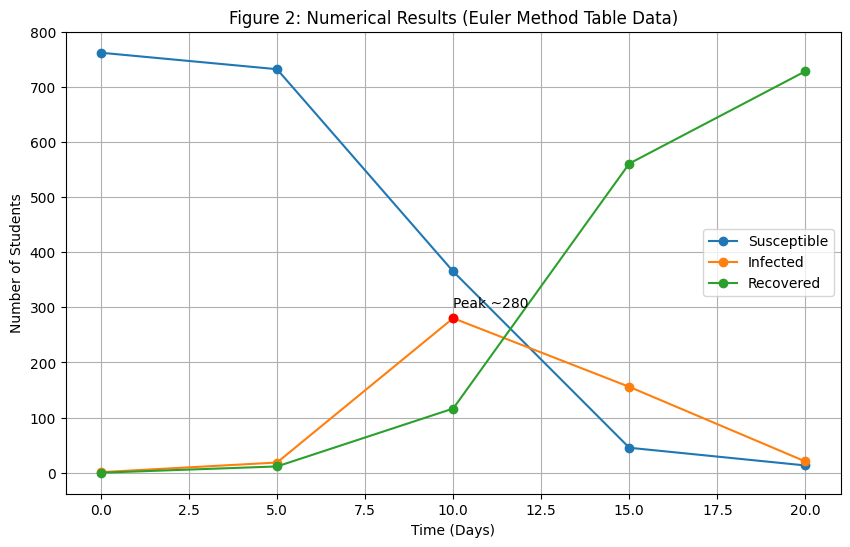

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# DATA FROM YOUR TABLE
# -----------------------------
days = np.array([0, 5, 10, 15, 20])

S = np.array([762.0, 732.1, 365.2, 45.3, 13.2])
I = np.array([1.0, 18.5, 280.4, 155.8, 20.4])
R = np.array([0.0, 11.4, 116.4, 560.9, 728.4])

# -----------------------------
# FIGURE 2 PLOT
# -----------------------------
plt.figure(figsize=(10,6))

plt.plot(days, S, marker='o', label="Susceptible")
plt.plot(days, I, marker='o', label="Infected")
plt.plot(days, R, marker='o', label="Recovered")

# Highlight peak infection (Day 10)
plt.scatter(10, 280.4, color="red", zorder=5)
plt.text(10, 280.4 + 20, "Peak ~280", fontsize=10)

plt.title("Figure 2: Numerical Results (Euler Method Table Data)")
plt.xlabel("Time (Days)")
plt.ylabel("Number of Students")
plt.grid(True)
plt.legend()

plt.show()